In [ ]:
! pip install kaggle
! mkdir ~/.kaggle
! cp /content/drive/MyDrive/kaggle.json ~/.kaggle/kaggle.json
! chmod 600 ~/.kaggle/kaggle.json

! kaggle datasets download iabhishekofficial/mobile-price-classification
! unzip mobile-price-classification.zip

cp: cannot stat '/content/drive/MyDrive/kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/iabhishekofficial/mobile-price-classification
License(s): unknown
  0% 0.00/70.6k [00:00<?, ?B/s]
100% 70.6k/70.6k [00:00<00:00, 52.8MB/s]
Archive:  mobile-price-classification.zip
  inflating: test.csv                
  inflating: train.csv               


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

#### CSV Dataset

In [ ]:
# Load mobile price dataset into dataframe
mobile_df = pd.read_csv('train.csv').dropna()
print(mobile_df.price_range.unique())
mobile_df.head()

[1 2 3 0]


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [ ]:
# Seperate features and target
mb_X = mobile_df.drop(columns=['price_range']).values.astype(np.float32)
mb_y = mobile_df.price_range.values

# Standardize features
scaler = StandardScaler()
mb_X = scaler.fit_transform(mb_X)
# ^^^^^^^^

# Convert to tensors
mb_X = torch.tensor(mb_X)
mb_y = torch.tensor(mb_y)

# Create train and test datasets
mb_train_set = TensorDataset(mb_X, mb_y)
train_split = 0.8
mb_train_size = int(train_split * len(mb_train_set))
mb_test_size = len(mb_train_set) - mb_train_size
mb_train_set, mb_test_set = torch.utils.data.random_split(mb_train_set, [mb_train_size, mb_test_size])

# Create dataloaders
mb_train_loader = DataLoader(mb_train_set, batch_size=16, shuffle=True)
mb_test_loader = DataLoader(mb_test_set, batch_size=16, shuffle=True)

print(len(mb_train_set), len(mb_test_set))
print(len(mb_train_loader), len(mb_test_loader))

1600 400
100 25


#### Functions and Models for use

In [ ]:
class MLP_CSV(nn.Module):
    def __init__(self):
        super(MLP_CSV, self).__init__()
        self.fc1 = nn.Sequential(
            nn.Linear(in_features=20, out_features=128), # 20 input features
            nn.ReLU(),
        )
        self.fc2 = nn.Sequential(
            nn.Linear(in_features=128, out_features=64),
            nn.ReLU(),
        )
        self.fc3 = nn.Sequential(
            nn.Linear(in_features=64, out_features=32),
            nn.ReLU(),
        )
        self.out = nn.Linear(in_features=32, out_features=4)  # 4 output for classification

    def forward(self, x):
        x = self.fc1(x)
        x = self.fc2(x)
        x = self.fc3(x)
        x = self.out(x)
        return x

class MLP_MNIST(nn.Module):
    def __init__(self):
        super(MLP_MNIST, self).__init__()
        self.fc1 = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=8*8, out_features=32), # 8*8 = 64 resized input pixels
            nn.ReLU(),
        )
        self.fc2 = nn.Sequential(
            nn.Linear(in_features=32, out_features=24),
            nn.ReLU(),
        )
        self.fc3 = nn.Sequential(
            nn.Linear(in_features=24, out_features=16),
            nn.ReLU(),
        )
        self.out = nn.Linear(in_features=16, out_features=10)  # 10 output for numbers

    def forward(self, x):
        x = self.fc1(x)
        x = self.fc2(x)
        x = self.fc3(x)
        x = self.out(x)
        return x

In [ ]:
def training_loop(train_dl, test_dl, model, n_epochs=200):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    # Your optimizer and loss function
    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    loss_fn = nn.CrossEntropyLoss()
    # ^^^^^^^^

    n_show_loss = n_epochs // 10 if n_epochs > 10 else 1
    train_history = {"train_loss":[], "validate_loss":[],
                     "train_acc":[], "validate_acc":[]}
    # Begin training loop
    for epoch in range(n_epochs):
        # Train loop
        train_loss, train_correct = 0, 0
        model.train(True)
        for X_t, y_t in train_dl:
            X_t, y_t = X_t.to(device), y_t.to(device)
            optimizer.zero_grad()
            y_pred = model(X_t)
            # This is your training loss calculation
            loss = loss_fn(y_pred, y_t)
            loss.backward()
            # ^^^^^^^^
            optimizer.step()
            train_loss += loss.item()
            train_correct += (y_pred.argmax(1) == y_t).float().sum().item()
        train_history["train_loss"].append(train_loss / len(train_dl))
        train_history["train_acc"].append(train_correct / len(train_dl.dataset))

        # Test loop
        valid_loss, valid_correct = 0, 0
        model.eval()
        with torch.no_grad():
            for X_v, y_v in test_dl:
                X_v, y_v = X_v.to(device), y_v.to(device)
                y_predv = model(X_v)
                vloss = loss_fn(y_predv.squeeze(), y_v.squeeze())
                valid_loss += vloss.item()
                valid_correct += (y_predv.argmax(1) == y_v).float().sum().item()
        train_history["validate_loss"].append(valid_loss / len(test_dl))
        train_history["validate_acc"].append(valid_correct / len(test_dl.dataset))

        if ((epoch+1) % n_show_loss == 0) or (epoch == n_epochs-1):
            print(f"Epochs {epoch+1}".ljust(12),
                  f"train loss {train_history['train_loss'][-1]:.6f}",
                  f"valid loss {train_history['validate_loss'][-1]:.6f}",
                  f"train acc {train_history['train_acc'][-1]:.6f}",
                  f"valid acc {train_history['validate_acc'][-1]:.6f}")

    return train_history

def plot_result(history):
    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_figwidth(10)
    fig.suptitle("Train vs Validation")
    ax1.plot(history["train_acc"], label="Train")
    ax1.plot(history["validate_acc"], label="Validation")
    ax1.legend()
    ax1.set_title("Accuracy")

    ax2.plot(history["train_loss"], label="Train")
    ax2.plot(history["validate_loss"], label="Validation")
    ax2.legend()
    ax2.set_title("Loss")
    fig.show()


----
## HW
----
### - CSV Dataset
Mobile price dataset ที่กำหนดมีข้อมูลเบื้องต้น ดังนี้
- จำนวน Features = 20 (RAM, Internal memory, Battery, ...)
- Target คือ `price_range` โดยมีทั้งหมด 4 ค่า คือ 0, 1, 2, 3 (Low cost, Medium cost, High cost, Very high cost)

> กำหนดให้ใช้โมเดล `MLP_CSV` เป็นต้นแบบ การ train ให้ใช้จำนวน `epochs` = 200, `optimizer` = Adam, `learning_rate` = 0.0001, `train_split` = 0.8, `batch_size` = 16, ไม่ใช้ Learning rate scheduler

'

1.) ให้ทดลอง train โมเดลโดยใช้ training loop ที่ให้มาหรือเขียนขึ้นเอง แบบธรรมดาไม่มีการปรับเพิ่มเติม ใช้เพื่อเป็นผลลัพธ์ Baseline สำหรับข้อต่อ ๆ ไป

- > แคปรูปผลลัพธ์ใหม่ 1 รูป

2.) ให้ทดลอง train โมเดลโดยใช้ L2 Regularizer เพิ่มในข้อ 1.) รวมทั้งหมด 2 แบบ คือ
  1. ใช้ L2 แบบ Marginal loss โดย `lambda` = [0.03, 0.01, 0.005] (เพิ่ม L2 loss ใน Training loop)
  2. ใช้ L2 แบบ Weight decay โดย `weight_decay` = [0.06, 0.01, 0.005] (ปรับ param ใน `optimizer`)

- > แคปรูปผลลัพธ์ใหม่ทั้งหมด 6 รูป พร้อมกับแสดงส่วนที่แก้ไขเพื่อทำ Marginal loss ภายใน Training loop และ วิเคราะห์เปรียบเทียบผลลัพธ์ที่ได้ทั้งหมดกับข้อ 1.)

3.) ให้ทดลอง train โมเดลโดยใช้ Dropout เพิ่มในข้อ 1.) ภายในชั้น fc1, fc2 และ fc3 และแทนค่า `p` ในแต่ละชั้นเป็นค่าดังต่อไปนี้
  1. fc1, fc2, fc3 = 0.5, 0.3, 0.2
  2. fc1, fc2, fc3 = 0.3, 0.2, 0.1
  3. fc1, fc2, fc3 = 0.2, 0.2, 0.2

- > แคปรูปผลลัพธ์ใหม่ทั้งหมด 3 รูป และ วิเคราะห์เปรียบเทียบผลลัพธ์ที่ได้กับข้อ 1.)

4.) ให้ทดลอง train โมเดล `MLP_CSV` ต้นแบบจากข้อ 1.) อีกครั้ง พร้อมกับ train โมเดลที่ใช้ BatchNorm เพิ่มในข้อ 1.) ภายในชั้น fc1, fc2 และ fc3 (ใช้ `nn.BatchNorm1d`) แต่จะมีการปรับในส่วนการเตรียม Mobile price Dataset ดังนี้
  1. โมเดลที่ใช้ BatchNorm ใช้ Dataset ที่ **ผ่าน** การทำ Standardized ด้วย `StandardScaler()` เทียบกับผลลัพธ์ข้อ 1.)
  2. โมเดล `MLP_CSV` ต้นแบบจากข้อ 1.) ใช้ Dataset ที่ **ไม่ผ่าน** การทำ Standardized
  3. โมเดลที่ใช้ BatchNorm ใช้ Dataset ที่ **ไม่ผ่าน** การทำ Standardized เทียบกับผลลัพธ์ข้อ 4.2)

- > แคปรูปผลลัพธ์ใหม่ทั้งหมด 3 รูป และ วิเคราะห์เปรียบเทียบผลลัพธ์ที่ได้

'

----

### - Torchvision Dataset

MNIST dataset จาก torchvision
- ภาพตัวเลขเขียนด้วยลายมือ
- ขนาด 28x28 pixel จะได้จำนวน features = 784
- Target = เลข 0 - 9 (10 ตัว)

```python
import torchvision
from torchvision import transforms
from torchvision.transforms import v2
import ...

# Your own transform
transforms = v2.Compose([
                v2.ToImage(),
                v2.ToDtype(torch.float32, scale=True),
                ...,
                ...])

# Optimizer, criterion (loss), and other hyper-pars
# model = ...
# optimizer = ...
# criterion = ...
# batch_size = ...
# scheduler = ...
# other = ...

# Download train-valid(test) Dataset
mnist_train_data = torchvision.datasets.MNIST('./Image/train_directory/', transform=transforms, download=True, train=True)
mnist_train_loader = torch.utils.data.DataLoader(mnist_train_data, batch_size=batch_size, shuffle=True)

mnist_test_data = torchvision.datasets.MNIST('./Image/test_directory/', transform=transforms, download=True, train=False)
mnist_valid_loader = torch.utils.data.DataLoader(mnist_test_data, batch_size=batch_size, shuffle=True)

# training loop
for epoch in range(epochs):
    model.train()
    # ...
    
    for inputs, labels in mnist_train_loader:
    # or
    for i, (inputs, labels) in enumerate(mnist_train_loader):
      outputs = model(inputs)
      loss = criterion(outputs, labels)
      # ...update...

    # Optional
    model.eval()
    with torch.no_grad():
      for vinputs, vlabels in mnist_valid_loader:
      # or
      for j, (vinputs, vlabels) in enumerate(mnist_valid_loader):
      voutputs = model(vinputs)
      loss = criterion(voutputs, vlabels)
      # ...non-update...

```

'

5.) ให้ทำการสร้าง Dataset ที่ใช้การ `transforms` เพิ่มเติมจากที่กำหนดไว้ โดยให้ลดขนาดภาพลงเหลือ 8x8 pixels (64 features) และเพิ่มการ Transform อีกอย่างน้อย 1 แบบ พร้อมกับสร้าง Dataloaders ที่มีจำนวน train : test = 80 : 20 ของจำนวน Dataset ทั้งหมดและใช้ `batch_size` = 16
* > แคปรูปส่วนกำหนดการ transforms และการทำ Dataloaders

ุ6.) ให้ทดลอง train โมเดล `MLP_MNIST` ต้นแบบที่กำหนด และ train โมเดลที่นักศึกษาออกแบบเอง (หรือเพิ่มต่อจากต้นแบบก็ได้) โดยกำหนดให้เพิ่มส่วนเทคนิคการใช้ L2 Regularizer, Dropout และ BatchNorm ภายในโมเดลที่ออกแบบเอง (เลือกอย่างน้อย 2 เทคนิค จะใส่ในทุก Hidden layers หรือไม่ก็ได้)

กำหนดไว้ว่าโมเดลที่นักศึกษาออกแบบ จะสามารถปรับจำนวน features ภายในได้อิสระ แต่ต้องมีจำนวน Hidden layers เท่ากับ `MLP_MNIST` ต้นแบบ และกำหนดการ train จะต้องใช้จำนวน `epochs` เท่ากัน โดยเลือกเองให้ <= 50, `optimizer` เลือกเอง และสามารถใช้ Learning rate scheduler ได้

* > จงทดลองหาผลลัพธ์การทำงาน ที่ทำให้ได้ประสิทธิภาพสูงกว่า `MLP_MNIST` ต้นแบบ เช่น Accuracy สูงกว่าเดิม
>
> แคปรูปผลลัพธ์การทำงาน โครงสร้างโมเดลสุดท้าย และอธิบายว่าใช้เทคนิคอะไร ทำอย่างไรบ้างที่ทำให้ได้ประสิทธิภาพสูงขึ้น

# เฉลย

## CSV

Epochs 20    train loss 0.156858 valid loss 0.209575 train acc 0.958750 valid acc 0.925000
Epochs 40    train loss 0.065004 valid loss 0.170329 train acc 0.988125 valid acc 0.937500
Epochs 60    train loss 0.027289 valid loss 0.172888 train acc 0.998125 valid acc 0.940000
Epochs 80    train loss 0.010360 valid loss 0.190133 train acc 1.000000 valid acc 0.937500
Epochs 100   train loss 0.003562 valid loss 0.227540 train acc 1.000000 valid acc 0.935000
Epochs 120   train loss 0.001203 valid loss 0.249277 train acc 1.000000 valid acc 0.935000
Epochs 140   train loss 0.000385 valid loss 0.273820 train acc 1.000000 valid acc 0.932500
Epochs 160   train loss 0.000125 valid loss 0.305879 train acc 1.000000 valid acc 0.930000
Epochs 180   train loss 0.000041 valid loss 0.348483 train acc 1.000000 valid acc 0.932500
Epochs 200   train loss 0.000014 valid loss 0.377181 train acc 1.000000 valid acc 0.932500


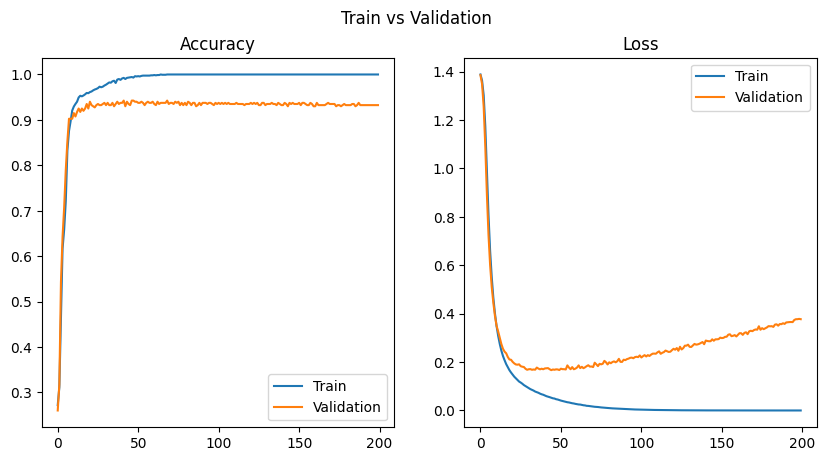

In [ ]:
model = MLP_CSV()
his = training_loop(mb_train_loader, mb_test_loader, model) # normal
plot_result(his) # Baseline

### L2

Epochs 20    train loss 1.295334 valid loss 1.050590 train acc 0.513125 valid acc 0.447500
Epochs 40    train loss 0.987639 valid loss 0.501389 train acc 0.909375 valid acc 0.892500
Epochs 60    train loss 0.967198 valid loss 0.439673 train acc 0.936875 valid acc 0.922500
Epochs 80    train loss 0.961046 valid loss 0.425410 train acc 0.943750 valid acc 0.915000
Epochs 100   train loss 0.958350 valid loss 0.417726 train acc 0.943125 valid acc 0.927500
Epochs 120   train loss 0.956067 valid loss 0.415368 train acc 0.943125 valid acc 0.912500
Epochs 140   train loss 0.955124 valid loss 0.411595 train acc 0.945625 valid acc 0.917500
Epochs 160   train loss 0.954088 valid loss 0.410027 train acc 0.945625 valid acc 0.917500
Epochs 180   train loss 0.952892 valid loss 0.407094 train acc 0.941250 valid acc 0.920000
Epochs 200   train loss 0.952431 valid loss 0.405577 train acc 0.946250 valid acc 0.907500


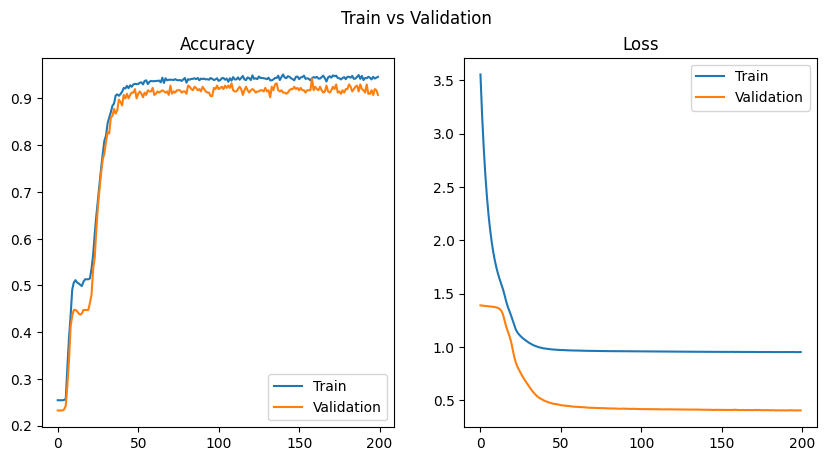

In [ ]:
model = MLP_CSV()
his = training_loop(mb_train_loader, mb_test_loader, model) # loss lambda = 0.03
plot_result(his) # worse than normal

Epochs 20    train loss 0.697694 valid loss 0.292324 train acc 0.957500 valid acc 0.925000
Epochs 40    train loss 0.575439 valid loss 0.225599 train acc 0.980625 valid acc 0.937500
Epochs 60    train loss 0.529181 valid loss 0.204294 train acc 0.988750 valid acc 0.932500
Epochs 80    train loss 0.504723 valid loss 0.197323 train acc 0.990000 valid acc 0.935000
Epochs 100   train loss 0.491391 valid loss 0.192055 train acc 0.989375 valid acc 0.940000
Epochs 120   train loss 0.482812 valid loss 0.189496 train acc 0.990000 valid acc 0.937500
Epochs 140   train loss 0.477024 valid loss 0.187540 train acc 0.991250 valid acc 0.940000
Epochs 160   train loss 0.472901 valid loss 0.185757 train acc 0.992500 valid acc 0.942500
Epochs 180   train loss 0.469726 valid loss 0.185603 train acc 0.991875 valid acc 0.945000
Epochs 200   train loss 0.466548 valid loss 0.183727 train acc 0.992500 valid acc 0.952500


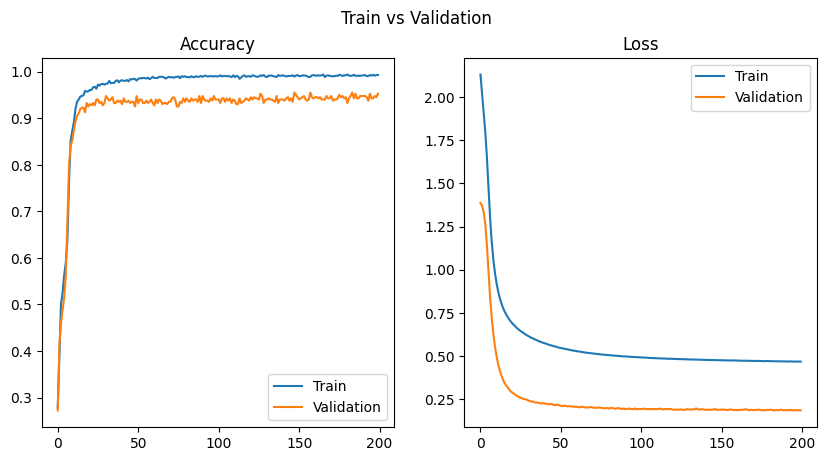

In [ ]:
model = MLP_CSV()
his = training_loop(mb_train_loader, mb_test_loader, model) # loss lambda = 0.01
plot_result(his) # same or better than normal

Epochs 20    train loss 0.520664 valid loss 0.241628 train acc 0.963125 valid acc 0.927500
Epochs 40    train loss 0.420578 valid loss 0.173577 train acc 0.985625 valid acc 0.935000
Epochs 60    train loss 0.375088 valid loss 0.155548 train acc 0.991250 valid acc 0.942500
Epochs 80    train loss 0.345983 valid loss 0.149047 train acc 0.995625 valid acc 0.937500
Epochs 100   train loss 0.327450 valid loss 0.147234 train acc 0.996250 valid acc 0.932500
Epochs 120   train loss 0.315759 valid loss 0.143289 train acc 0.998750 valid acc 0.935000
Epochs 140   train loss 0.306443 valid loss 0.138472 train acc 0.998750 valid acc 0.945000
Epochs 160   train loss 0.300699 valid loss 0.142251 train acc 0.998750 valid acc 0.942500
Epochs 180   train loss 0.295891 valid loss 0.136499 train acc 0.999375 valid acc 0.950000
Epochs 200   train loss 0.292489 valid loss 0.141635 train acc 1.000000 valid acc 0.942500


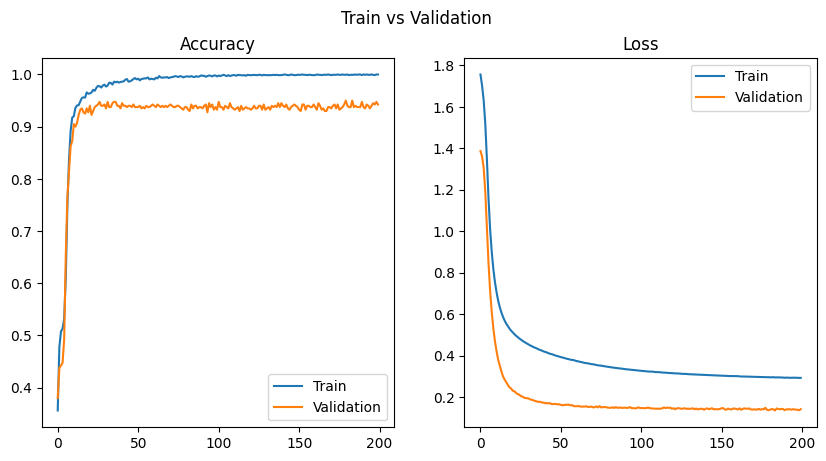

In [ ]:
model = MLP_CSV()
his = training_loop(mb_train_loader, mb_test_loader, model) # loss lambda = 0.005
plot_result(his) # better than normal

Epochs 20    train loss 1.266523 valid loss 1.245979 train acc 0.513125 valid acc 0.447500
Epochs 40    train loss 0.470752 valid loss 0.501835 train acc 0.916250 valid acc 0.882500
Epochs 60    train loss 0.412748 valid loss 0.443674 train acc 0.940625 valid acc 0.915000
Epochs 80    train loss 0.398600 valid loss 0.429716 train acc 0.940625 valid acc 0.890000
Epochs 100   train loss 0.391513 valid loss 0.420566 train acc 0.939375 valid acc 0.915000
Epochs 120   train loss 0.386605 valid loss 0.415632 train acc 0.945000 valid acc 0.917500
Epochs 140   train loss 0.383896 valid loss 0.413605 train acc 0.950000 valid acc 0.920000
Epochs 160   train loss 0.381365 valid loss 0.410114 train acc 0.944375 valid acc 0.902500
Epochs 180   train loss 0.377370 valid loss 0.406361 train acc 0.947500 valid acc 0.922500
Epochs 200   train loss 0.376788 valid loss 0.403628 train acc 0.943125 valid acc 0.925000


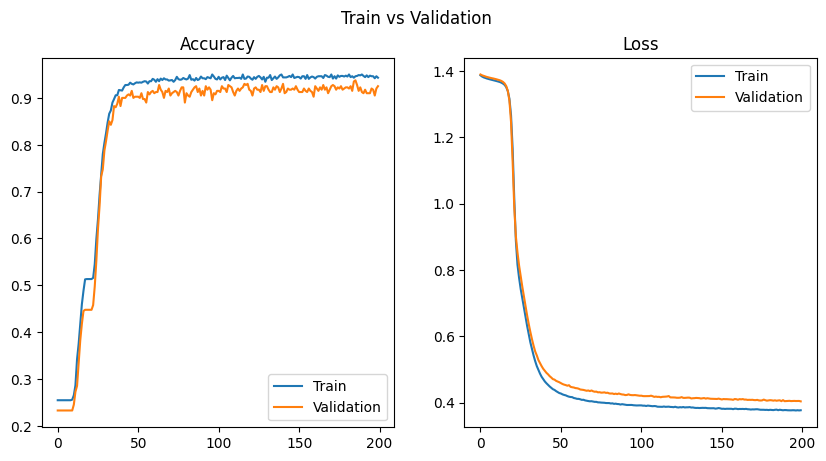

In [ ]:
model = MLP_CSV()
his = training_loop(mb_train_loader, mb_test_loader, model) # weight decay = 0.06
plot_result(his) # worse than normal

Epochs 20    train loss 0.206251 valid loss 0.249944 train acc 0.956875 valid acc 0.935000
Epochs 40    train loss 0.119866 valid loss 0.181346 train acc 0.984375 valid acc 0.937500
Epochs 60    train loss 0.094288 valid loss 0.161644 train acc 0.991250 valid acc 0.945000
Epochs 80    train loss 0.081216 valid loss 0.154369 train acc 0.993125 valid acc 0.947500
Epochs 100   train loss 0.074382 valid loss 0.152424 train acc 0.994375 valid acc 0.945000
Epochs 120   train loss 0.070022 valid loss 0.148306 train acc 0.996875 valid acc 0.947500
Epochs 140   train loss 0.066519 valid loss 0.148252 train acc 0.997500 valid acc 0.942500
Epochs 160   train loss 0.064616 valid loss 0.150141 train acc 0.998750 valid acc 0.937500
Epochs 180   train loss 0.063755 valid loss 0.148362 train acc 0.999375 valid acc 0.942500
Epochs 200   train loss 0.063021 valid loss 0.150477 train acc 0.999375 valid acc 0.935000


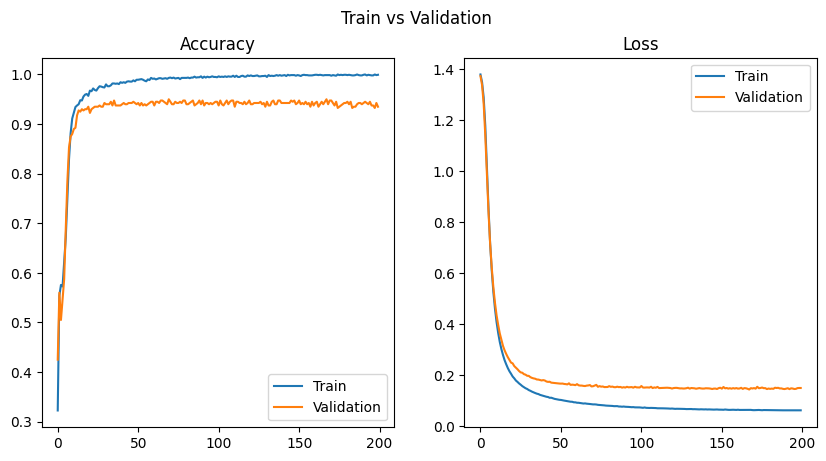

In [ ]:
model = MLP_CSV()
his = training_loop(mb_train_loader, mb_test_loader, model) # weight decay = 0.01
plot_result(his) # same or better than normal

Epochs 20    train loss 0.178355 valid loss 0.222047 train acc 0.962500 valid acc 0.927500
Epochs 40    train loss 0.086578 valid loss 0.147905 train acc 0.986250 valid acc 0.945000
Epochs 60    train loss 0.056396 valid loss 0.132032 train acc 0.996250 valid acc 0.942500
Epochs 80    train loss 0.042648 valid loss 0.121406 train acc 0.999375 valid acc 0.957500
Epochs 100   train loss 0.035096 valid loss 0.120756 train acc 1.000000 valid acc 0.945000
Epochs 120   train loss 0.032014 valid loss 0.122666 train acc 1.000000 valid acc 0.950000
Epochs 140   train loss 0.029310 valid loss 0.118109 train acc 1.000000 valid acc 0.947500
Epochs 160   train loss 0.028077 valid loss 0.116067 train acc 1.000000 valid acc 0.950000
Epochs 180   train loss 0.027265 valid loss 0.117069 train acc 1.000000 valid acc 0.947500
Epochs 200   train loss 0.026489 valid loss 0.122234 train acc 1.000000 valid acc 0.945000


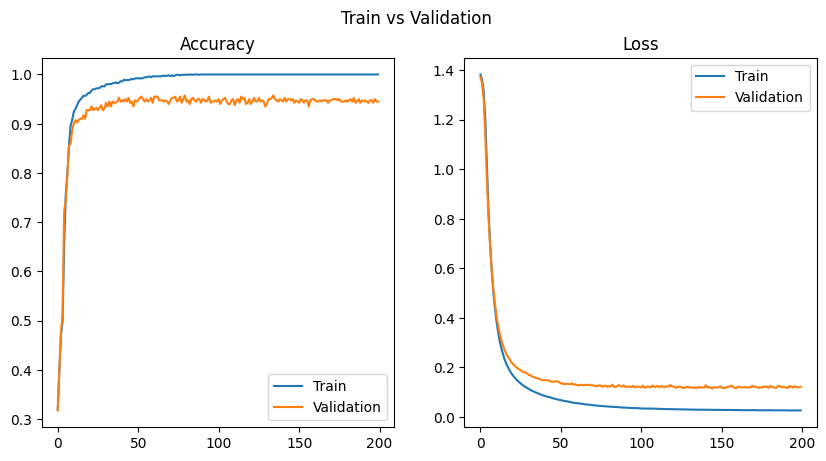

In [ ]:
model = MLP_CSV()
his = training_loop(mb_train_loader, mb_test_loader, model) # weight decay = 0.005
plot_result(his) # better than normal

### Dropout

Epochs 20    train loss 0.585971 valid loss 0.452241 train acc 0.758750 valid acc 0.870000
Epochs 40    train loss 0.430064 valid loss 0.274982 train acc 0.821875 valid acc 0.907500
Epochs 60    train loss 0.343037 valid loss 0.229856 train acc 0.870000 valid acc 0.910000
Epochs 80    train loss 0.302902 valid loss 0.196301 train acc 0.878125 valid acc 0.910000
Epochs 100   train loss 0.265300 valid loss 0.177085 train acc 0.896875 valid acc 0.922500
Epochs 120   train loss 0.249101 valid loss 0.173703 train acc 0.905625 valid acc 0.925000
Epochs 140   train loss 0.208690 valid loss 0.154721 train acc 0.923750 valid acc 0.925000
Epochs 160   train loss 0.203258 valid loss 0.149160 train acc 0.920625 valid acc 0.930000
Epochs 180   train loss 0.176937 valid loss 0.152529 train acc 0.926250 valid acc 0.930000
Epochs 200   train loss 0.187264 valid loss 0.148750 train acc 0.927500 valid acc 0.925000


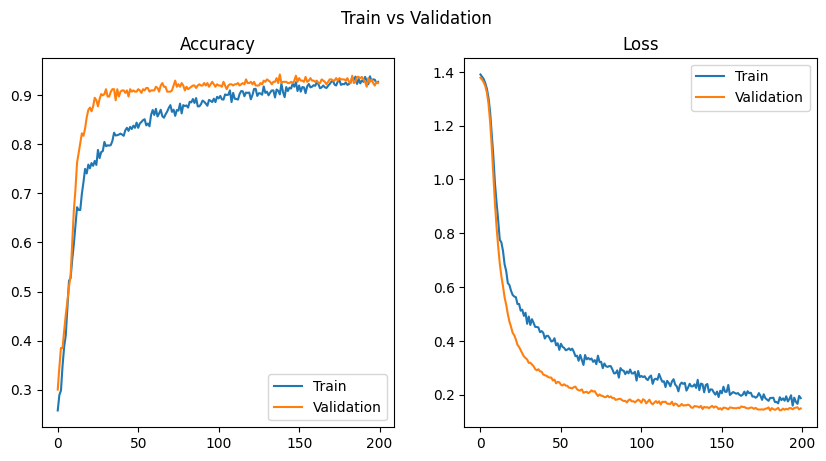

In [ ]:
model = MLP_CSV()
his = training_loop(mb_train_loader, mb_test_loader, model) # Drop 0.5 0.3 0.2
plot_result(his) # same or worse than normal

Epochs 20    train loss 0.415097 valid loss 0.318664 train acc 0.818125 valid acc 0.892500
Epochs 40    train loss 0.294711 valid loss 0.208559 train acc 0.879375 valid acc 0.920000
Epochs 60    train loss 0.206519 valid loss 0.165892 train acc 0.920625 valid acc 0.942500
Epochs 80    train loss 0.179379 valid loss 0.156660 train acc 0.922500 valid acc 0.932500
Epochs 100   train loss 0.155739 valid loss 0.147342 train acc 0.937500 valid acc 0.932500
Epochs 120   train loss 0.140748 valid loss 0.142844 train acc 0.942500 valid acc 0.925000
Epochs 140   train loss 0.127615 valid loss 0.141876 train acc 0.950625 valid acc 0.927500
Epochs 160   train loss 0.119479 valid loss 0.140977 train acc 0.948750 valid acc 0.935000
Epochs 180   train loss 0.121903 valid loss 0.137971 train acc 0.951250 valid acc 0.937500
Epochs 200   train loss 0.098003 valid loss 0.141780 train acc 0.966875 valid acc 0.937500


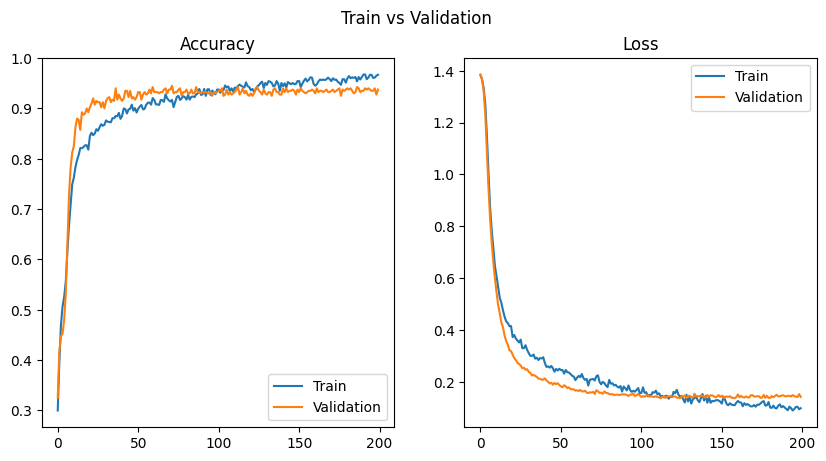

In [ ]:
model = MLP_CSV()
his = training_loop(mb_train_loader, mb_test_loader, model) # Drop 0.3 0.2 0.1
plot_result(his) # same or better than normal

Epochs 20    train loss 0.381317 valid loss 0.303342 train acc 0.847500 valid acc 0.917500
Epochs 40    train loss 0.250817 valid loss 0.187866 train acc 0.905625 valid acc 0.935000
Epochs 60    train loss 0.201228 valid loss 0.157668 train acc 0.923125 valid acc 0.935000
Epochs 80    train loss 0.170467 valid loss 0.136939 train acc 0.927500 valid acc 0.930000
Epochs 100   train loss 0.151412 valid loss 0.130959 train acc 0.941250 valid acc 0.932500
Epochs 120   train loss 0.129574 valid loss 0.127380 train acc 0.953125 valid acc 0.947500
Epochs 140   train loss 0.116422 valid loss 0.125180 train acc 0.960625 valid acc 0.945000
Epochs 160   train loss 0.098951 valid loss 0.120707 train acc 0.964375 valid acc 0.952500
Epochs 180   train loss 0.088345 valid loss 0.135232 train acc 0.968750 valid acc 0.947500
Epochs 200   train loss 0.077473 valid loss 0.130318 train acc 0.970625 valid acc 0.952500


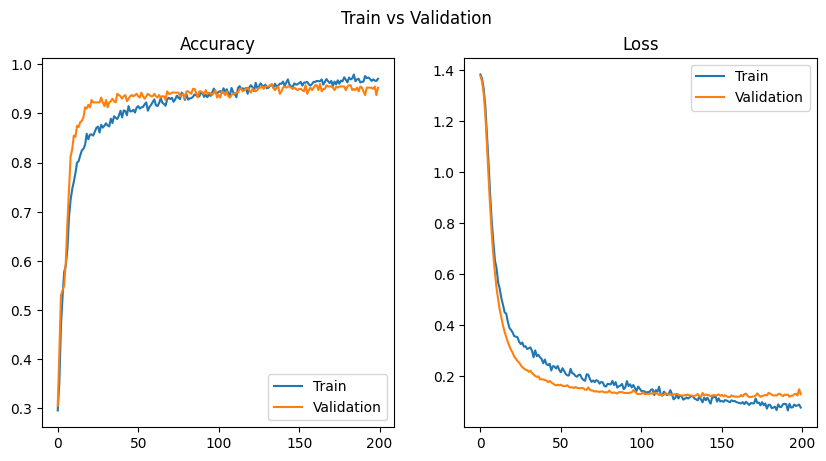

In [ ]:
model = MLP_CSV()
his = training_loop(mb_train_loader, mb_test_loader, model) # Drop 0.2 0.2 0.2
plot_result(his) # same or better than normal

### Batchnorm

Epochs 20    train loss 0.508301 valid loss 0.465891 train acc 0.805000 valid acc 0.850000
Epochs 40    train loss 0.365460 valid loss 0.362927 train acc 0.857500 valid acc 0.857500
Epochs 60    train loss 0.315872 valid loss 0.369107 train acc 0.883750 valid acc 0.850000
Epochs 80    train loss 0.294390 valid loss 0.419718 train acc 0.894375 valid acc 0.825000
Epochs 100   train loss 0.225170 valid loss 0.455119 train acc 0.915625 valid acc 0.800000
Epochs 120   train loss 0.211878 valid loss 0.429901 train acc 0.920625 valid acc 0.810000
Epochs 140   train loss 0.135318 valid loss 0.512203 train acc 0.953750 valid acc 0.787500
Epochs 160   train loss 0.127834 valid loss 0.478069 train acc 0.951875 valid acc 0.805000
Epochs 180   train loss 0.118424 valid loss 0.486195 train acc 0.963125 valid acc 0.805000
Epochs 200   train loss 0.085676 valid loss 0.461804 train acc 0.974375 valid acc 0.810000


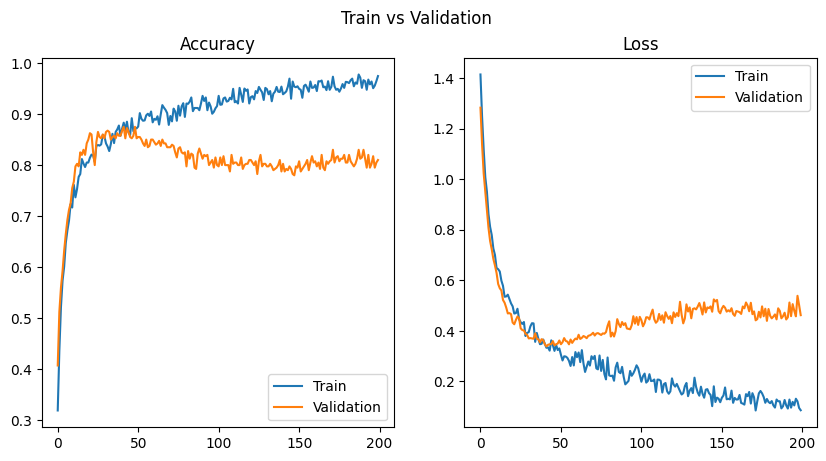

In [ ]:
model = MLP_CSV()
his = training_loop(mb_train_loader, mb_test_loader, model) # batchnorm with StandardScaler()
plot_result(his) # worse than normal with StandardScaler()

Epochs 20    train loss 0.678983 valid loss 0.706435 train acc 0.682500 valid acc 0.642500
Epochs 40    train loss 0.635072 valid loss 0.667596 train acc 0.711250 valid acc 0.702500
Epochs 60    train loss 0.568224 valid loss 0.672451 train acc 0.736250 valid acc 0.697500
Epochs 80    train loss 0.549350 valid loss 0.714252 train acc 0.742500 valid acc 0.692500
Epochs 100   train loss 0.517643 valid loss 0.624847 train acc 0.764375 valid acc 0.692500
Epochs 120   train loss 0.520229 valid loss 0.575166 train acc 0.763125 valid acc 0.745000
Epochs 140   train loss 0.498818 valid loss 0.571192 train acc 0.784375 valid acc 0.750000
Epochs 160   train loss 0.481274 valid loss 0.550887 train acc 0.781250 valid acc 0.750000
Epochs 180   train loss 0.485467 valid loss 0.595062 train acc 0.780625 valid acc 0.707500
Epochs 200   train loss 0.456274 valid loss 0.628321 train acc 0.791250 valid acc 0.722500


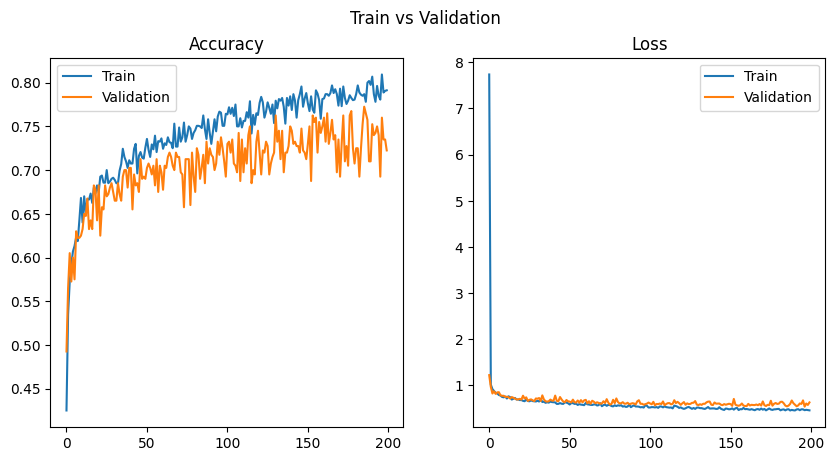

In [ ]:
model = MLP_CSV()
his = training_loop(mb_train_loader, mb_test_loader, model) # normal without standardized
plot_result(his) # worse than normal with StandardScaler()

Epochs 20    train loss 0.424980 valid loss 0.284825 train acc 0.830000 valid acc 0.940000
Epochs 40    train loss 0.392670 valid loss 0.260121 train acc 0.844375 valid acc 0.947500
Epochs 60    train loss 0.367132 valid loss 0.255799 train acc 0.855000 valid acc 0.915000
Epochs 80    train loss 0.329118 valid loss 0.269095 train acc 0.871875 valid acc 0.925000
Epochs 100   train loss 0.386064 valid loss 0.222809 train acc 0.849375 valid acc 0.922500
Epochs 120   train loss 0.309446 valid loss 0.226426 train acc 0.877500 valid acc 0.927500
Epochs 140   train loss 0.313076 valid loss 0.209669 train acc 0.871250 valid acc 0.935000
Epochs 160   train loss 0.292867 valid loss 0.329793 train acc 0.879375 valid acc 0.925000
Epochs 180   train loss 0.271179 valid loss 0.323519 train acc 0.887500 valid acc 0.935000
Epochs 200   train loss 0.266622 valid loss 0.349964 train acc 0.897500 valid acc 0.917500


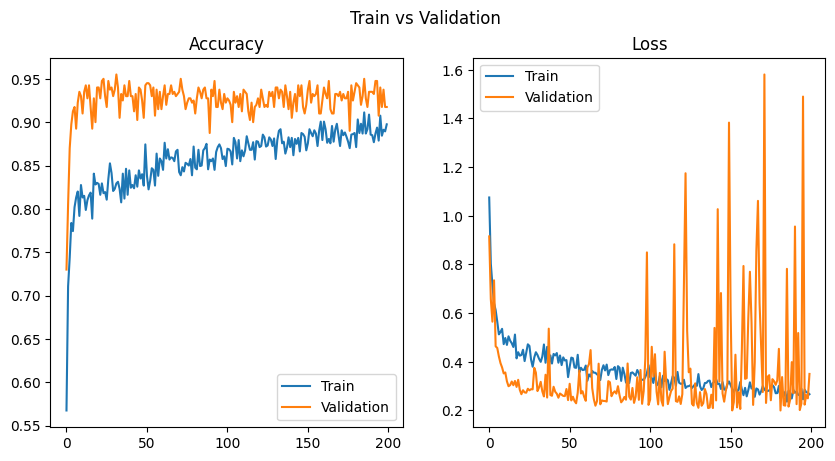

In [ ]:
model = MLP_CSV()
his = training_loop(mb_train_loader, mb_test_loader, model) # batchnorm without standardized
plot_result(his) # about same with normal with StandardScaler() (can be better or worse sometimes)

## Torchvision

In [ ]:
import torchvision
from torchvision import transforms
from torchvision.transforms import v2

# Your own transform
transforms = v2.Compose([
                v2.ToImage(),
                v2.ToDtype(torch.float32, scale=True),
                v2.Resize(size=8),
                v2.RandomRotation(degrees=(0, 20)),
                v2.Grayscale()
                ])

# Download Dataset
mnist_data = torchvision.datasets.MNIST('./Image/', transform=transforms, download=True)

In [ ]:
# Create training dataset and validation dataset
train_split = 0.8
train_size = int(train_split * len(mnist_data))
test_size = len(mnist_data) - train_size
training_set, validation_set = torch.utils.data.random_split(mnist_data, [train_size, test_size])

# Create dataloaders for our datasets; shuffle for training, not for validation
training_loader = torch.utils.data.DataLoader(training_set, batch_size=16, shuffle=True)
validation_loader = torch.utils.data.DataLoader(validation_set, batch_size=16, shuffle=False)

# print(next(iter(training_loader))[0].size())

In [ ]:
def training_loop(train_dl, test_dl, model, n_epochs=200):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    # Your optimizer and loss function
    optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=0.005)
    loss_fn = nn.CrossEntropyLoss()
    # ^^^^^^^^

    n_show_loss = n_epochs // 10 if n_epochs > 10 else 1
    train_history = {"train_loss":[], "validate_loss":[],
                     "train_acc":[], "validate_acc":[]}
    # Begin training loop
    for epoch in range(n_epochs):
        # Train loop
        train_loss, train_correct = 0, 0
        model.train(True)
        for X_t, y_t in train_dl:
            X_t, y_t = X_t.to(device), y_t.to(device)
            optimizer.zero_grad()
            y_pred = model(X_t)
            # This is your training loss calculation
            loss = loss_fn(y_pred, y_t)
            loss.backward()
            # ^^^^^^^^
            optimizer.step()
            train_loss += loss.item()
            train_correct += (y_pred.argmax(1) == y_t).float().sum().item()
        train_history["train_loss"].append(train_loss / len(train_dl))
        train_history["train_acc"].append(train_correct / len(train_dl.dataset))

        # Test loop
        valid_loss, valid_correct = 0, 0
        model.eval()
        with torch.no_grad():
            for X_v, y_v in test_dl:
                X_v, y_v = X_v.to(device), y_v.to(device)
                y_predv = model(X_v)
                vloss = loss_fn(y_predv.squeeze(), y_v.squeeze())
                valid_loss += vloss.item()
                valid_correct += (y_predv.argmax(1) == y_v).float().sum().item()
        train_history["validate_loss"].append(valid_loss / len(test_dl))
        train_history["validate_acc"].append(valid_correct / len(test_dl.dataset))

        if ((epoch+1) % n_show_loss == 0) or (epoch == n_epochs-1):
            print(f"Epochs {epoch+1}".ljust(12),
                  f"train loss {train_history['train_loss'][-1]:.6f}",
                  f"valid loss {train_history['validate_loss'][-1]:.6f}",
                  f"train acc {train_history['train_acc'][-1]:.6f}",
                  f"valid acc {train_history['validate_acc'][-1]:.6f}")

    return train_history

class MLP_MNIST(nn.Module):
    def __init__(self):
        super(MLP_MNIST, self).__init__()
        self.fc1 = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=8*8, out_features=32), # 8*8 = 64 resized input pixels
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.BatchNorm1d(32)
        )
        self.fc2 = nn.Sequential(
            nn.Linear(in_features=32, out_features=24),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.BatchNorm1d(24)
        )
        self.fc3 = nn.Sequential(
            nn.Linear(in_features=24, out_features=16),
            nn.ReLU(),
            nn.BatchNorm1d(16)
        )
        self.out = nn.Linear(in_features=16, out_features=10)  # 10 output for numbers

    def forward(self, x):
        x = self.fc1(x)
        x = self.fc2(x)
        x = self.fc3(x)
        x = self.out(x)
        return x

Epochs 3     train loss 0.822518 valid loss 0.766304 train acc 0.716854 valid acc 0.736000
Epochs 6     train loss 0.655052 valid loss 0.629836 train acc 0.779917 valid acc 0.785833
Epochs 9     train loss 0.571915 valid loss 0.551013 train acc 0.814979 valid acc 0.822750
Epochs 12    train loss 0.503039 valid loss 0.483389 train acc 0.841875 valid acc 0.846083
Epochs 15    train loss 0.451683 valid loss 0.435788 train acc 0.861146 valid acc 0.863333
Epochs 18    train loss 0.410769 valid loss 0.399969 train acc 0.877000 valid acc 0.876583
Epochs 21    train loss 0.381428 valid loss 0.372727 train acc 0.884333 valid acc 0.883917
Epochs 24    train loss 0.359483 valid loss 0.352167 train acc 0.891646 valid acc 0.891500
Epochs 27    train loss 0.341866 valid loss 0.343503 train acc 0.895771 valid acc 0.894083
Epochs 30    train loss 0.327110 valid loss 0.321124 train acc 0.899875 valid acc 0.900250


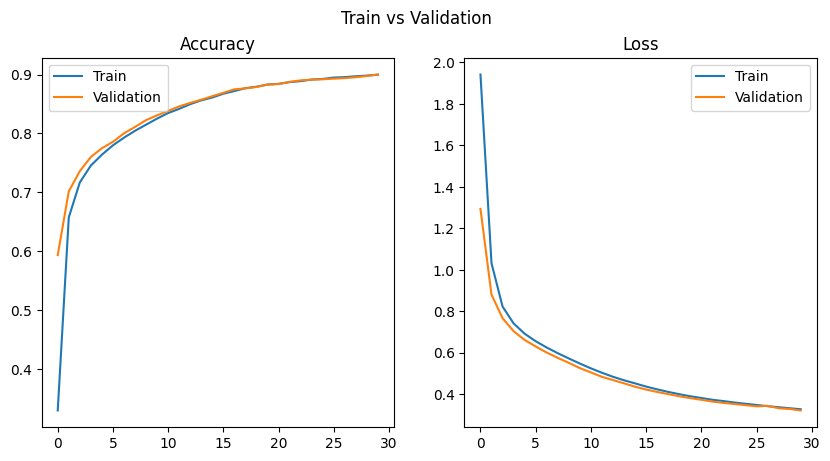

In [ ]:
model = MLP_MNIST()
his = training_loop(training_loader, validation_loader, model, n_epochs=30) # Base no technique added, transform grey scale only
plot_result(his) # Adam optim

Epochs 3     train loss 0.909298 valid loss 0.562261 train acc 0.714958 valid acc 0.852667
Epochs 6     train loss 0.711462 valid loss 0.435711 train acc 0.778167 valid acc 0.880333
Epochs 9     train loss 0.624459 valid loss 0.379399 train acc 0.810042 valid acc 0.893333
Epochs 12    train loss 0.590448 valid loss 0.354273 train acc 0.819792 valid acc 0.896750
Epochs 15    train loss 0.560461 valid loss 0.338654 train acc 0.830354 valid acc 0.905083
Epochs 18    train loss 0.534575 valid loss 0.320575 train acc 0.841271 valid acc 0.910667
Epochs 21    train loss 0.523953 valid loss 0.315348 train acc 0.843833 valid acc 0.911417
Epochs 24    train loss 0.508934 valid loss 0.306433 train acc 0.847167 valid acc 0.911000
Epochs 27    train loss 0.502625 valid loss 0.300100 train acc 0.851313 valid acc 0.915917
Epochs 30    train loss 0.497136 valid loss 0.301975 train acc 0.851042 valid acc 0.913667


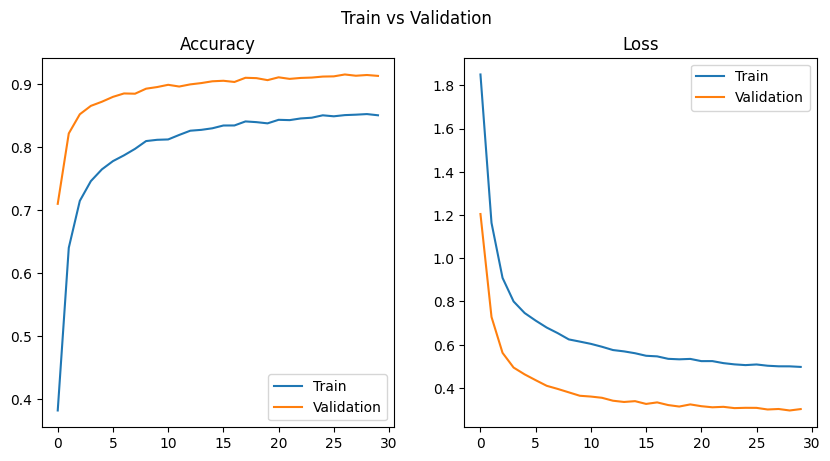

In [ ]:
model = MLP_MNIST()
his = training_loop(training_loader, validation_loader, model, n_epochs=30) # All technique added, transform grey scale and rotate 20 deg
plot_result(his)